<a href="https://colab.research.google.com/github/nickolas-eisenbarth/Freshman-notebook/blob/main/lectures/Lecture36.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recap:
* ##  Interpolation in 1D: `scipy.interpolate.interp1d`
* ##  Curve fitting: `scipy.optimize.curve_fit`

# Today:
* ## More about `scipy.optimize` in optimization applications
  * optimization
  * root finding
  * linear programing

## Note: There are a lot of math behind these optimization algorithms. You will take optimization courses which dig into the algorithms in other classes. Here we only want to show you how to use the toolbox: formulate the problem, define inputs and get outputs (without exactly knowing how).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import linalg as la

#1. Optimization : `scipy.optimize`

Optimization involves finding the minimum (or maximum) of a function $f(x)$ subject to constraints. Mathematically:
$$ \text{minimize:} f(x),\quad x\in \mathbb R^n$$
subject to
* equality constraints: $h(x) = 0$
* inequality constraints: $g(x) \leq 0$.

### For problems without constraints, `scipy.optimize` typically uses gradient-based methods.
Without much of the mathematical details, the gradient method (e.g., gradient descent) can be understood intuitively with the analogy of hiking down a hill in foggy weather. Here’s how it works:

**Scenario: Hiking Down a Hill**

Imagine you are standing on a hilltop and your goal is to find the lowest point in the valley (i.e., the minimum of a function). However, there is thick fog, so you cannot see very far—only the slope of the ground immediately around you.

How Gradient Descent Works

1. **Gradient as the Slope:**
	* The gradient is like the slope of the ground under your feet.
	* If the slope is steep in a certain direction, it means the ground is descending quickly that way, so you should move in that direction.

2.	**Taking Small Steps:**
	* To avoid tripping or overshooting, you take small, careful steps downhill.
	* The step size corresponds to the learning rate in gradient descent.
  
3.	**Step by Step:**
	* After each step, you reevaluate the slope of the ground (recompute the gradient) and adjust your direction.
	* This process repeats until the slope is almost flat (i.e., you reach the bottom of the valley or the minimum of the function).

4.	**Challenges Along the Way:**
	* Flat Areas: If the ground is flat (near-zero gradient), your steps will become very small, and progress will be slow.
	* Steep Cliffs: If the slope is too steep, you might take overly large steps and miss the valley bottom entirely (similar to an unstable learning rate).
	* Multiple Valleys: If there are multiple valleys (local minima), you might get stuck in one that isn’t the deepest.




In [ ]:
# Def a function with one arg x
def f(x):
    return x**4 - 10 * x**2

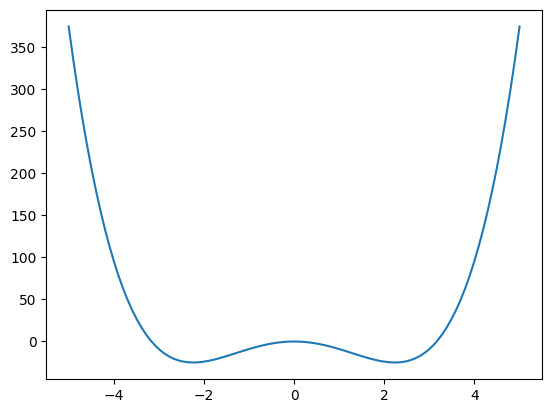

In [ ]:
x = np.linspace(-5, 5, 100)
plt.plot(x, f(x));

In [ ]:
help(optimize.minimize)

Help on function minimize in module scipy.optimize._minimize:

minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)
    Minimization of scalar function of one or more variables.

    Parameters
    ----------
    fun : callable
        The objective function to be minimized::

            fun(x, *args) -> float

        where ``x`` is a 1-D array with shape (n,) and ``args``
        is a tuple of the fixed parameters needed to completely
        specify the function.

        Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
        ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
        Rather than passing ``f0`` as the callable, wrap it to accept
        only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
        callable, where ``my_args`` (tuple) and ``my_kwargs`` (dict) have been
        gathered before invoking this

In [ ]:
# find the argmin(function)
results = optimize.minimize(f, 4)  # function and initial guess
results

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -24.99999999999999
        x: [ 2.236e+00]
      nit: 7
      jac: [ 1.431e-06]
 hess_inv: [[ 2.497e-02]]
     nfev: 16
     njev: 8

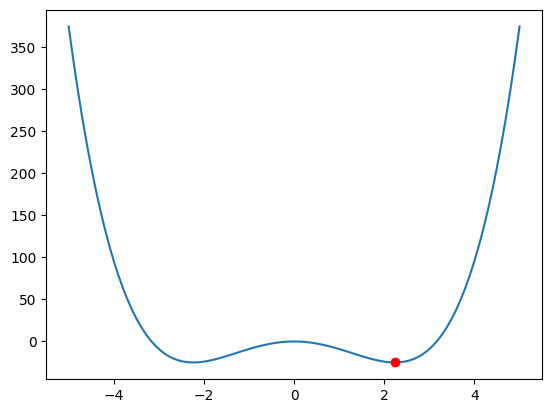

In [ ]:
# let's plot the min points we found
plt.plot(x, f(x))
results = optimize.minimize(f, 4)
plt.plot(results.x, f(results.x), "ro");

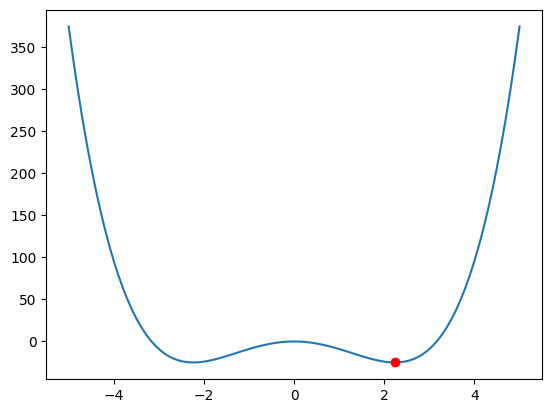

In [ ]:
# TODO: What if we change the initial guess??? Try to change 4 to 0.5
plt.plot(x, f(x))
results = optimize.minimize(f, 0.5)
plt.plot(results.x, f(results.x), "ro");

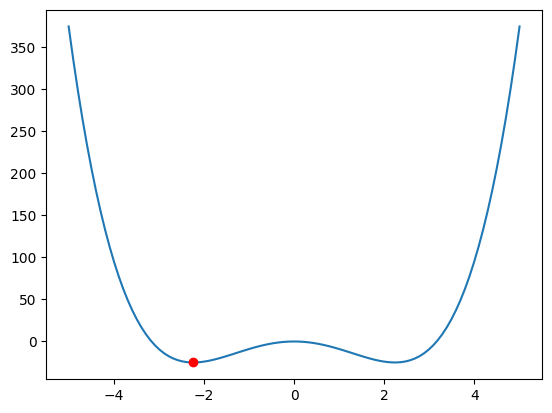

In [ ]:
# TODO: What if we change the initial guess??? Try to change 0.5 to 0
plt.plot(x, f(x))
results = optimize.minimize(f, -4)
plt.plot(results.x, f(results.x), "ro");

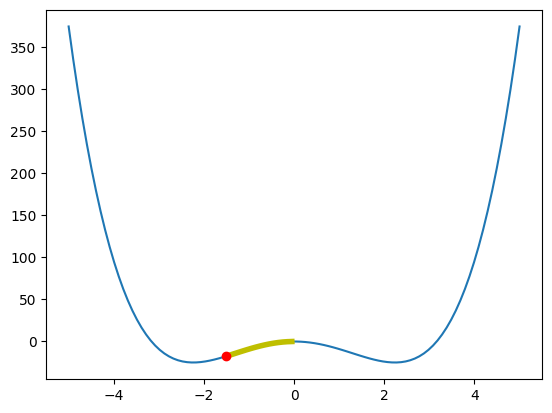

In [ ]:
# What happen if we define the bounds and find the min value
plt.plot(x, f(x))
results = optimize.minimize(f, -0.5, bounds=[(-1.5, 0)])
plt.plot(x[np.logical_and(x < 0, x > -1.5)], f(x[np.logical_and(x < 0, x > -1.5)]), "y-",linewidth = 4)
x_opt = results.x
plt.plot(x_opt, f(x_opt), "ro");

## Optimization Application Example:
You want to design a cylindrical water tank with a flat circular base and with top. The goal is to minimize the material cost (surface area) while meeting a volume requirement.

**Problem Formulation**

1.	Given:
*	The volume  $V$  of the tank must be 1,000 cubic meters.
*	Material costs are proportional to the surface area, so minimize the tank’s surface area.

2.	Variables:
*	$r$ : Radius of the tank’s base.
* $h$ : Height of the tank.

3.	Objective Function:
*	Minimize the surface area:

$$A = 2\pi r^2 + 2 \pi r h$$
  * $\pi r^2$ : Area of the base.
	* $2 \pi r h$ : Area of the side wall.

4.	Constraint:
*	The volume must be 1,000 cubic meters:

$$\pi r^2 h = 1000$$

5.	Bounds:
*	$r > 0 ,  h > 0$  (radius and height must be positive).

In [ ]:
# Given volume
required_volume = 1000  # cubic meters

# Objective function: Surface area (to be minimized)
def surface_area(params):
    r, h = params  # r: radius, h: height
    return 2*np.pi*r**2 +2*np.pi*r*h

# Constraint: Volume of the tank
def volume_constraint(params):
    r, h = params
    return np.pi*r**2*h-required_volume

# Bounds: Radius and height must be positive
bounds =[(1e-6,None),(1e-6,None)]

# Initial guess for radius and height
initial_guess = [1,2]

# Define constraints in the form required by `minimize`
constraints = {'type': 'eq','fun':volume_constraint}

# Perform the optimization
result = optimize.minimize(surface_area,initial_guess,method = 'SLSQP',bounds = bounds, constraints = constraints)
# SLSQP: sequeantial least square programing

# Extract the optimal radius and height
optimal_radius, optimal_height = result.x

# Print results
print("Optimal Radius:", optimal_radius)
print("Optimal Height:", optimal_height)
print("Minimum Surface Area:", surface_area(result.x))

Optimal Radius: 5.419262109509532
Optimal Height: 10.8385157651284
Minimum Surface Area: 553.5810444164229


# 2. Root Finding: solving for $x$ s.t. $f(x) = 0$

In [ ]:
# Apply the optimize.root function to find the root value making f() = 0
def f(x):
    return np.sin(x)

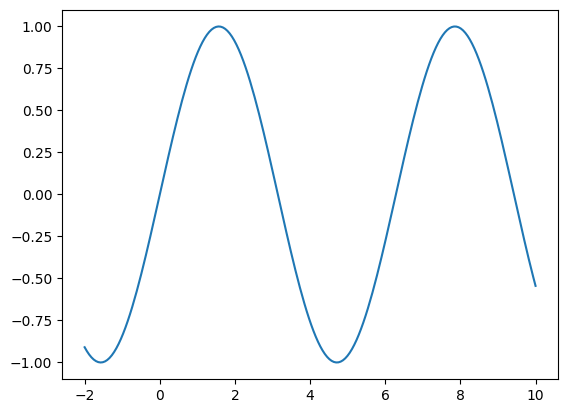

In [ ]:
x_fine = np.linspace(-2, 10, 200)
plt.plot(x_fine, f(x_fine))

In [ ]:
?optimize.root

In [ ]:
r = optimize.root(f, -1)
r.x

array([0.])

In [ ]:
f(r.x)

array([0.])

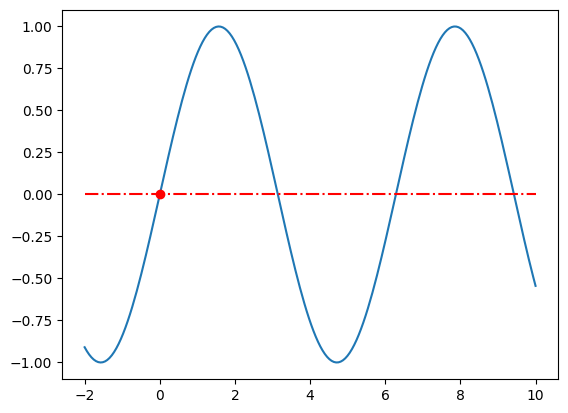

In [ ]:
x_fine = np.linspace(-2, 10, 200)
plt.plot(x_fine, f(x_fine))
plt.plot(r.x, f(r.x), "ro");
plt.plot(x_fine,0*x_fine,'r-.')

#3.  Linear programming
A very common case is linear programming (LP). These are optimization problems that can be written in the form

$$
\begin{equation}
\begin{split}
\text{minimize} \;\; & c^{T}x  \\
\text{subject to} \;\; & A_{ub}x \leq b_{ub} \\
& A_{eq}x = b_{eq}
\end{split}
\end{equation}
$$

Here, we are finding the vector $x$ that minimizes the dot product $c^T x$, where $c$ is some fixed vector, out of all $x$ that satisfy $A_{ub}x \leq b_{ub}$ and $A_{eq}x = b_{eq}$, where $A_{ub}$ and $A_{eq}$ are matrices and $b_{ub}$ and $b_{eq}$ are vectors.

## Exercise
Using Google and reading documentation are important parts of programming. [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html) comes with specialized functions for solving linear programming problems.

Figure out how to solve LPs using `scipy.optimize`, and solve the following LP:
$$
\begin{equation}
\begin{split}
\text{minimize} \;\; & x_1 + 2 x_2  \\
\text{subject to} \;\; & x_1 \leq 1 \\
& 5 x_1 + x_2 \geq 0
\end{split}
\end{equation}
$$

Note that the problem is equivalent to

$$
\begin{equation}
\begin{split}
\text{minimize} \;\; & c^T x  \\
\text{subject to} \;\; & A_{ub}x \leq b_{ub} \\
& A_{eq}x = b_{eq}
\end{split}
\end{equation}
$$
where
$$
c = \begin{pmatrix} 1 \\ 2 \end{pmatrix} \qquad
A_{ub} = \begin{pmatrix} 1 & 0 \\ -5 & -1 \end{pmatrix}, \qquad
b_{ub} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \qquad
A_{eq} = 0, \qquad
b_{eq} = 0.
$$

We can see this because
$$
 \begin{pmatrix} 1 & 0 \\ -5 & -1 \end{pmatrix} \begin{pmatrix} x_1 \\ x_2 \end{pmatrix} = \begin{pmatrix} x_1 \\ -5x_1 - x_2 \end{pmatrix}
$$

In [ ]:
?optimize.linprog

In [ ]:
c = np.array([1, 2])
Aub = np.array([[1, 0], [-5, -1]])
bub = np.array([1, 0])

In [ ]:
# #Answer
x1_bounds = (None, None)
x2_bounds = (None, None)
results = optimize.linprog(c, A_ub=Aub, b_ub=bub, bounds=[x1_bounds, x2_bounds])
results

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -9.0
              x: [ 1.000e+00 -5.000e+00]
            nit: 0
          lower:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00]
                 marginals: [-9.000e+00 -2.000e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

In [ ]:
# rest
c.T @ results.x

np.float64(-9.0)

In [ ]:
Aub @ results.x

array([1., 0.])

In [ ]:
bub

array([1, 0])

In [ ]:
la.norm(Aub @ results.x) <= la.norm(bub)

np.True_

## Appliation example:
Imagine you are Mark Watney and now you are stuck on Mars. You have a few options of food to grow on Mars: potatoes, corns and beans. Your goal is to minimize the cost of water in growing food while meeting certain nutrition requirements to survive.

**problem description**

1.	Objective:
Minimize the total cost of water in planting all food.

2.	Constraints:
*	Each food item provides specific amounts of nutrients (e.g., calories, protein, vitamins).
*	The diet must meet or exceed daily requirements for each nutrient.

3.	Variables:

*	Let  $x_i$  represent the amount of the  $i$ -th food item in the diet.

**Mathematical Formulation**
Assume $x_1$ the amount of potato, $x_2$ the amount corn and $x_3$ the amount of beans.
1.	Objective Function:

$$\text{Minimize: } C = c_1 x_1 + c_2 x_2 + \dots + c_n x_n$$

where  $c_i$  is the amount of water needed per unit of food item  $i$ . $c_1= 2, c_2= 3, c_3 = 1.5$.

2.	Constraints:
* Nutritional constraints:

$$a_{11} x_1 + a_{12} x_2 + \dots + a_{1n} x_n \geq b_1 \quad (\text{Calories})$$
$a_{11} = 500, a_{12} = 300, a_{13} =200$


$$a_{21} x_1 + a_{22} x_2 + \dots + a_{2n} x_n \geq b_2 \quad (\text{Protein})$$
$a_{21}= 30,a_{22} = 20, a_{23} =15$
  

$$a_{31} x_1 + a_{32} x_2 + \dots + a_{3n} x_n \geq b_2 \quad (\text{Vitamin})$$
$a_{31}=10, a_{32} =10, a_{33} =10$

*	General form:  $Ax \geq b$ , where  $A$  is the nutrient content matrix.
*	Non-negativity:  $x_i \geq 0$  (you can’t have negative food quantities).

In [ ]:
# Costs (water) of food items (per unit)
cost = [2,3,1.5]  # Cost of potato,corn,beans

# Nutritional content matrix (rows: nutrients, columns: foods)
# Each column represents [calories, protein, vitamins]
A =[[-500,-300,-200], # calories
    [-30,-20,-15],  # proteins
    [-10,-10,-10] # vitamins
    ]

# Nutritional requirements (negative for >= constraint)
b = [-2000,-70,-20]               # Minimum requirements for calories, protein, vitamins

# Bounds for the variables (non-negative food quantities)
x_bounds = [(0,None),(0,None),(0,None)]        # No upper limit for food quantities

# Solve the linear programming problem
result = optimize.linprog(cost, A_ub=A, b_ub=b, bounds=x_bounds,method ='highs')

# Print results
if result.success:
    print("Optimal Food Quantities:", result.x)
    print("Total Cost of Water:", result.fun)
else:
    print("Optimization failed:", result.message)

Optimal Food Quantities: [4. 0. 0.]
Total Cost of Water: 8.0


### Okay, Potato wins :)

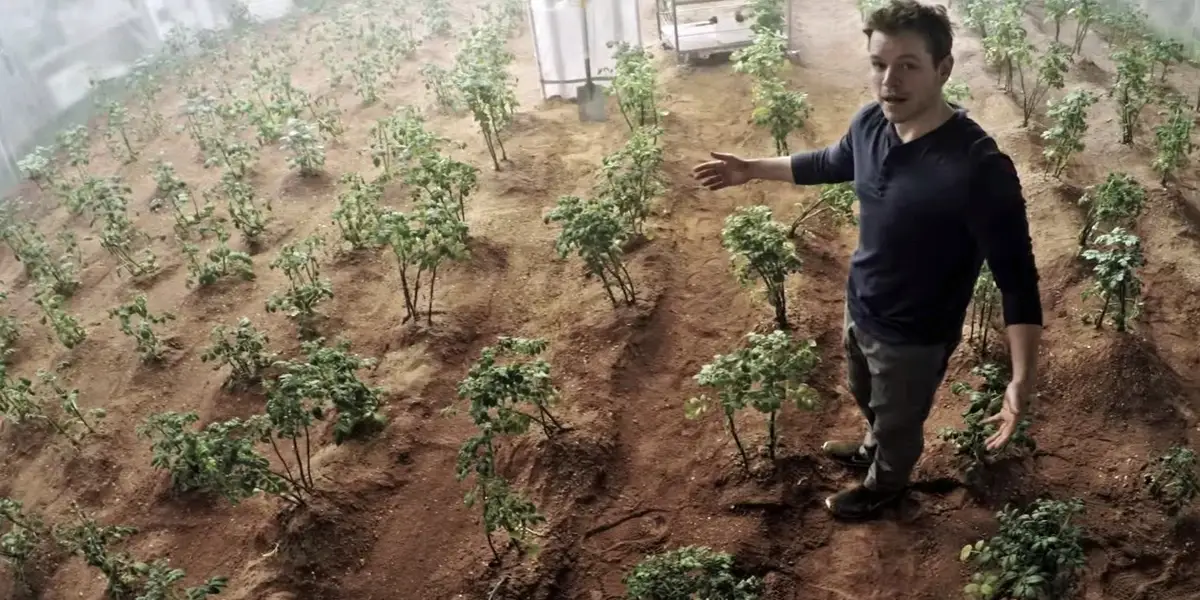